# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [920]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

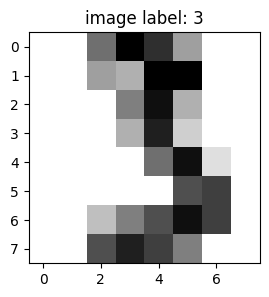

In [921]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [922]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [923]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [924]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [925]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [926]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True)
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / np.sum(exp, axis=-1, keepdims=True)


Let's make sure that this works one vector at a time (and check that the components sum to one):

In [927]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [928]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [929]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [930]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [931]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [932]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [933]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [934]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [935]:
class LogisticRegression:

    def __init__(self, input_size, output_size):
        # Initialize the weights and biases with random numbers
        self.W = np.random.uniform(size=(input_size, output_size),
                                   high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size,
                                   high=0.1, low=-0.1)
        
        # Store the input size and output size
        self.output_size = output_size
        self.input_size = input_size
        
    def forward(self, X):
        # Compute the linear combination of the input and weights
        Z = np.dot(X, self.W)+self.b
        return softmax(Z)
    
    def predict(self, X):
        # Return the most probable class for each sample in X
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)
            
    def loss(self, X, y):
        # Compute the negative log likelihood over the data provided
        y_onehot = one_hot(self.output_size, y.astype(int))
        y_pred=self.forward(X)
        return nll(y_onehot,y_pred)
        return None

    def grad_loss(self, X, y_true, y_pred):
        # Compute the gradient of the loss with respect to W and b for a single sample (X, y_true)
        # y_pred is the output of the forward pass
    
        # Gradient with respect to weights
        grad_W = np.dot(X.T, (y_pred - y_true))
    
        # Gradient with respect to biases
        grad_b = np.sum(y_pred - y_true, axis=0)
    
        return grad_W, grad_b
    
# Raise an exception if you try to run this cell without having implemented the LogisticRegression class
model = LogisticRegression(input_size=64, output_size=10)
try:
    assert(model.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(model.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the LogisticRegression class.")

In [936]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

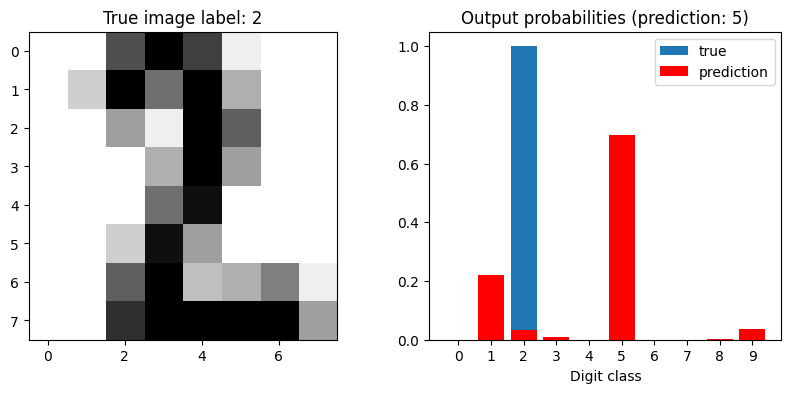

In [937]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx]);


    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)
    

Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [938]:
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)

learning_rate = 0.1

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b
    y_pred = lr.forward(x)
    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)

    # Update the weights and biases
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps (avoid empty slice at i==0)
    if i > 0 and i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))


Average NLL over the last 100 samples at step 100: 865
Average NLL over the last 100 samples at step 200: 1037
Average NLL over the last 100 samples at step 300: 242
Average NLL over the last 100 samples at step 400: 381
Average NLL over the last 100 samples at step 500: 438
Average NLL over the last 100 samples at step 600: 326
Average NLL over the last 100 samples at step 700: 546
Average NLL over the last 100 samples at step 800: 218
Average NLL over the last 100 samples at step 900: 275
Average NLL over the last 100 samples at step 1000: 590
Average NLL over the last 100 samples at step 1100: 276
Average NLL over the last 100 samples at step 1200: 104
Average NLL over the last 100 samples at step 1300: 377
Average NLL over the last 100 samples at step 1400: 276
Average NLL over the last 100 samples at step 1500: 322


Evaluate the trained model on the first example:

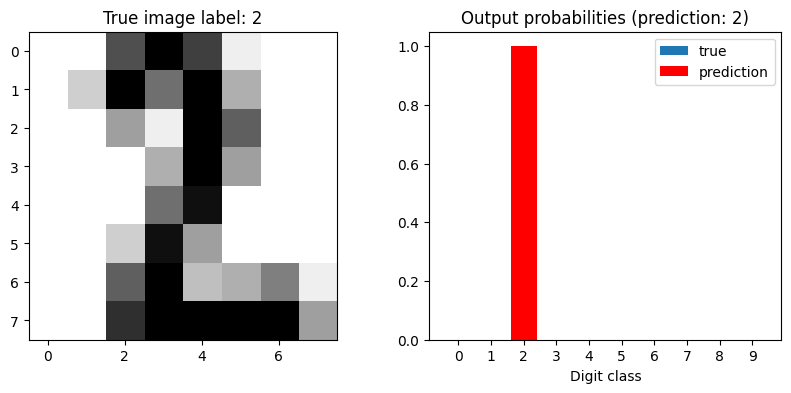

In [939]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

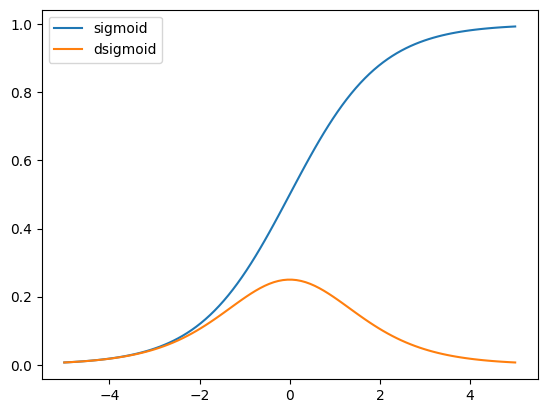

In [940]:
def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = np.clip(X, -500, 500) # This ensures that np.exp(X) doesn't overflow
    return 1/(1 + np.exp(-X))


def dsigmoid(X):
    return sigmoid(X)* (1-sigmoid(X))


x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [941]:
class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initializes the weights with random numbers
        self.W_h = np.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.Z_h = None
        self.H =None
        self.Z_o=None

    def forward_hidden(self, X):
        if len(X.shape)==1:
            X=X.reshape(1,-1)
        # Compute the linear combination of the input and weights
        self.Z_h = np.dot(X, self.W_h)+self.b_h
        self.H=sigmoid(self.Z_h)
        # Apply the sigmoid activation function
        return self.H
    def forward_output(self, H):
        if len(H.shape)==1:
            H=H.reshape(1,-1)
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = np.dot(H, self.W_o)+self.b_o
        exp_scores =np.exp(self.Z_o -np.max(self.Z_o, axis=-1, keepdims=True))

        # Apply the sigmoid activation function
        return exp_scores/ np.sum(exp_scores, axis=1, keepdims=True)

    def forward(self, X):
        if len(X.shape)==1:
            X=X.reshape(1,-1)
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)
        if X.shape[0]==1:
            Y=Y.flatten()
        else: 
            return Y

    def loss(self, X, y):
        y = y.astype(int)
        y_pred =self.forward(X)
        
        m = 1 if len(X.shape) == 1 else X.shape[0]
        y_one_hot = one_hot(self.output_size, y)
        
        # Ensure both are 2D for computation
        if len(y_pred.shape) == 1:
            y_pred = y_pred.reshape(1, -1)
        if len(y_one_hot.shape) == 1:
            y_one_hot = y_one_hot.reshape(1, -1)
            
        log_likelihood = -np.log(y_pred[np.arange(m), y] + 1e-8)
        loss = np.sum(log_likelihood) / m
        return loss

    def grad_loss(self, X, y_true):
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        if len(y_pred.shape) == 1:
            y_pred = y_pred.reshape(1, -1)
        if len(y_true_one_hot.shape) == 1:
            y_true_one_hot = y_true_one_hot.reshape(1, -1)

        m=X.shape[0]
        # Compute the error at the output layer
        error_o = (y_pred - y_true)/m

        # Compute the gradient of the loss with respect to W_o and b_o
        grad_W_o = np.dot(self.H.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Compute the error at the hidden layer
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)

        # Compute the gradient of the loss with respect to W_h and b_h
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        x = x[np.newaxis, :]
        if len(x.shape) == 1:
            x = x.reshape(1, -1)

        # Compute the gradient for the sample and update the weights
        self.H=self.forward_hidden(x)
        grads = self.grad_loss(x, y)
        clip_value=1.0
        for key in grads: grads[key]=np.clip(grads[key],-clip_value, clip_value)

        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)
    


In [956]:
# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet(input_size=64, hidden_size=32, output_size=10)
try:
    # Test with 2D input
    output_2d = nn.forward(np.zeros((1, 64)))
    print(f"2D input shape: {output_2d.shape}")
    
    # Test with 1D input  
    output_1d = nn.forward(np.zeros(64))
    print(f"1D input shape: {output_1d.shape}")
    
    # Test loss
    loss_val = nn.loss(np.zeros((1, 64)), np.zeros(1))
    print(f"Loss: {loss_val}")
    
    print("✅ NeuralNet implementation is working correctly!")
    
except Exception as e:
    print(f"❌ Error: {e}")

2D input shape: (10,)
1D input shape: (10,)
Loss: 2.430998699326111
✅ NeuralNet implementation is working correctly!


C:\Users\lionl\AppData\Local\Temp\ipykernel_27892\823482763.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  one_hot_vec[int(y)] = 1


In [957]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def dsigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

def one_hot(n_classes, y):
    if len(y.shape) == 0 or (len(y.shape) == 1 and y.shape[0] == 1):
        # Single sample
        one_hot_vec = np.zeros(n_classes)
        one_hot_vec[int(y)] = 1
        return one_hot_vec
    else:
        # Multiple samples
        m = len(y)
        one_hot_matrix = np.zeros((m, n_classes))
        one_hot_matrix[np.arange(m), y.astype(int)] = 1
        return one_hot_matrix

class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initializes the weights with random numbers
        self.W_h = np.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.Z_h = None
        self.H = None
        self.Z_o = None

    def forward_hidden(self, X):
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
        # Compute the linear combination of the input and weights
        self.Z_h = np.dot(X, self.W_h) + self.b_h
        self.H = sigmoid(self.Z_h)
        return self.H

    def forward_output(self, H):
        if len(H.shape) == 1:
            H = H.reshape(1, -1)
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = np.dot(H, self.W_o) + self.b_o
        # Apply softmax activation
        exp_scores = np.exp(self.Z_o - np.max(self.Z_o, axis=-1, keepdims=True))
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    def forward(self, X):
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)
        if X.shape[0] == 1:
            return Y.flatten()
        else:
            return Y

    def loss(self, X, y):
        y = y.astype(int)
        y_pred = self.forward(X)
        
        m = 1 if len(X.shape) == 1 else X.shape[0]
        y_one_hot = one_hot(self.output_size, y)
        
        # Ensure both are 2D for computation
        if len(y_pred.shape) == 1:
            y_pred = y_pred.reshape(1, -1)
        if len(y_one_hot.shape) == 1:
            y_one_hot = y_one_hot.reshape(1, -1)
            
        # Calculate cross-entropy loss
        log_likelihood = -np.log(y_pred[np.arange(m), y] + 1e-8)
        loss = np.sum(log_likelihood) / m
        return loss

    def grad_loss(self, X, y_true):
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
            
        # Convert y_true to one-hot encoding
        y_true_one_hot = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Ensure proper shapes
        if len(y_pred.shape) == 1:
            y_pred = y_pred.reshape(1, -1)
        if len(y_true_one_hot.shape) == 1:
            y_true_one_hot = y_true_one_hot.reshape(1, -1)

        m = X.shape[0]
        
        # Compute the error at the output layer
        error_o = (y_pred - y_true_one_hot) / m

        # Compute the gradient of the loss with respect to W_o and b_o
        grad_W_o = np.dot(self.H.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Compute the error at the hidden layer
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)

        # Compute the gradient of the loss with respect to W_h and b_h
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        if len(x.shape) == 1:
            x = x.reshape(1, -1)

        # Forward pass to populate H and Z_h
        self.forward_hidden(x)
        self.forward_output(self.H)
        
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)
        clip_value = 1.0
        for key in grads:
            grads[key] = np.clip(grads[key], -clip_value, clip_value)

        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        y_pred = self.forward(X)
        if len(y_pred.shape) == 1:
            return np.argmax(y_pred)
        else:
            return np.argmax(y_pred, axis=1)

    def accuracy(self, X, y):
        y_preds = self.predict(X)
        return np.mean(y_preds == y)

In [944]:
# Test the fixed implementation
nn = NeuralNet(input_size=64, hidden_size=50, output_size=10)

try:
    # Test with 2D input
    output_2d = nn.forward(np.zeros((1, 64)))
    print(f"2D input shape: {output_2d.shape}")
    
    # Test with 1D input  
    output_1d = nn.forward(np.zeros(64))
    print(f"1D input shape: {output_1d.shape}")
    
    # Test loss
    loss_val = nn.loss(np.zeros((1, 64)), np.zeros(1, dtype=int))
    print(f"Loss: {loss_val:.4f}")
    
    # Test prediction
    pred_2d = nn.predict(np.zeros((1, 64)))
    print(f"Prediction with 2D input: {pred_2d}")
    
    pred_1d = nn.predict(np.zeros(64))
    print(f"Prediction with 1D input: {pred_1d}")
    
    # Test training
    X_train = np.random.randn(5, 64)
    y_train = np.random.randint(0, 10, 5)
    
    initial_acc = nn.accuracy(X_train, y_train)
    print(f"Initial accuracy: {initial_acc:.4f}")
    
    # Train for a few epochs
    for epoch in range(10):
        for i in range(len(X_train)):
            nn.train(X_train[i], y_train[i], learning_rate=0.01)
    
    final_acc = nn.accuracy(X_train, y_train)
    print(f"Final accuracy: {final_acc:.4f}")
    
    print("✅ NeuralNet implementation is working correctly!")
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

2D input shape: (10,)
1D input shape: (10,)
Loss: 2.2828
Prediction with 2D input: 6
Prediction with 1D input: 6
Initial accuracy: 0.0000
Final accuracy: 0.6000
✅ NeuralNet implementation is working correctly!


C:\Users\lionl\AppData\Local\Temp\ipykernel_27892\823482763.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  one_hot_vec[int(y)] = 1


Once the code is written, we can test our model on a single sample:

In [958]:
n_hidden = 60
model = NeuralNet(n_features, n_hidden, n_classes)

In [959]:
model.loss(X_train, y_train)

np.float64(2.4232538110568407)

In [960]:
model.accuracy(X_train, y_train)

np.float64(0.0)

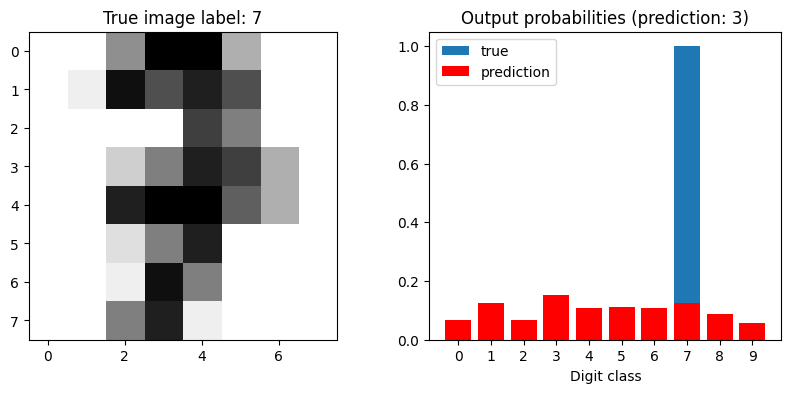

In [964]:
plot_prediction(model, sample_idx=2)

And now it's time to train!

In [966]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 2.42325, train acc: 0.000, test acc: 0.044
Epoch #1, train loss: 2.39321, train acc: 0.000, test acc: 0.048
Epoch #2, train loss: 2.36364, train acc: 0.000, test acc: 0.048
Epoch #3, train loss: 2.33457, train acc: 0.000, test acc: 0.056
Epoch #4, train loss: 2.30599, train acc: 0.000, test acc: 0.070
Epoch #5, train loss: 2.27790, train acc: 0.000, test acc: 0.093
Epoch #6, train loss: 2.25031, train acc: 0.000, test acc: 0.089
Epoch #7, train loss: 2.22323, train acc: 0.400, test acc: 0.100
Epoch #8, train loss: 2.19665, train acc: 0.400, test acc: 0.107
Epoch #9, train loss: 2.17058, train acc: 0.400, test acc: 0.100
Epoch #10, train loss: 2.14501, train acc: 0.600, test acc: 0.089
Epoch #11, train loss: 2.11996, train acc: 0.600, test acc: 0.093
Epoch #12, train loss: 2.09541, train acc: 0.600, test acc: 0.093
Epoch #13, train loss: 2.07138, train acc: 0.600, test acc: 0.089
Epoch #14, train loss: 2.04785, train acc: 0.600, test acc: 0.089
Epoch #15, train 

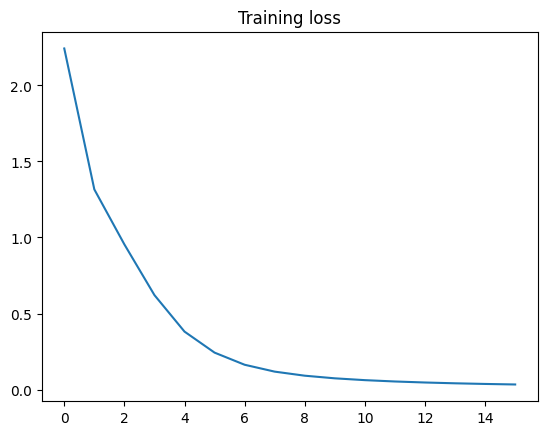

In [965]:
plt.plot(losses)
plt.title("Training loss");

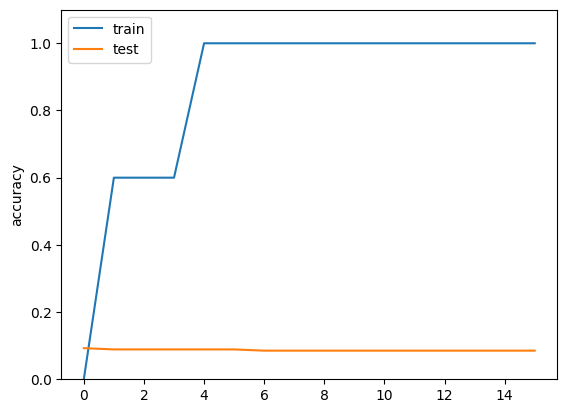

In [951]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

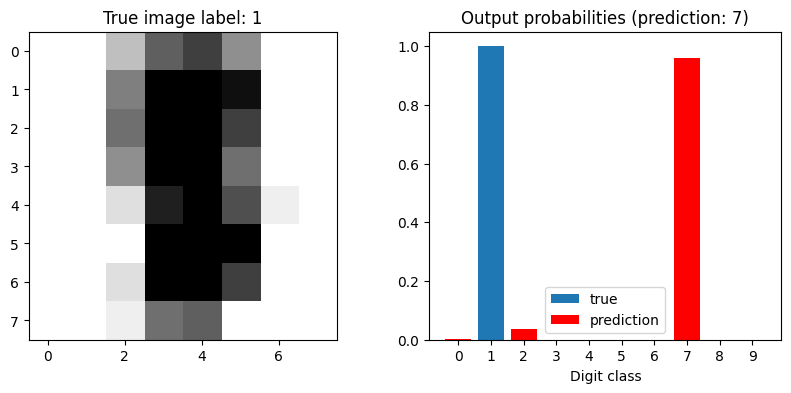

In [952]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

In [953]:
#Answer:the model is working correctly, however the accuracy would be improved with tuning hyperparameters and also increasing the hidden units or layers. 


Using simple plotting function...


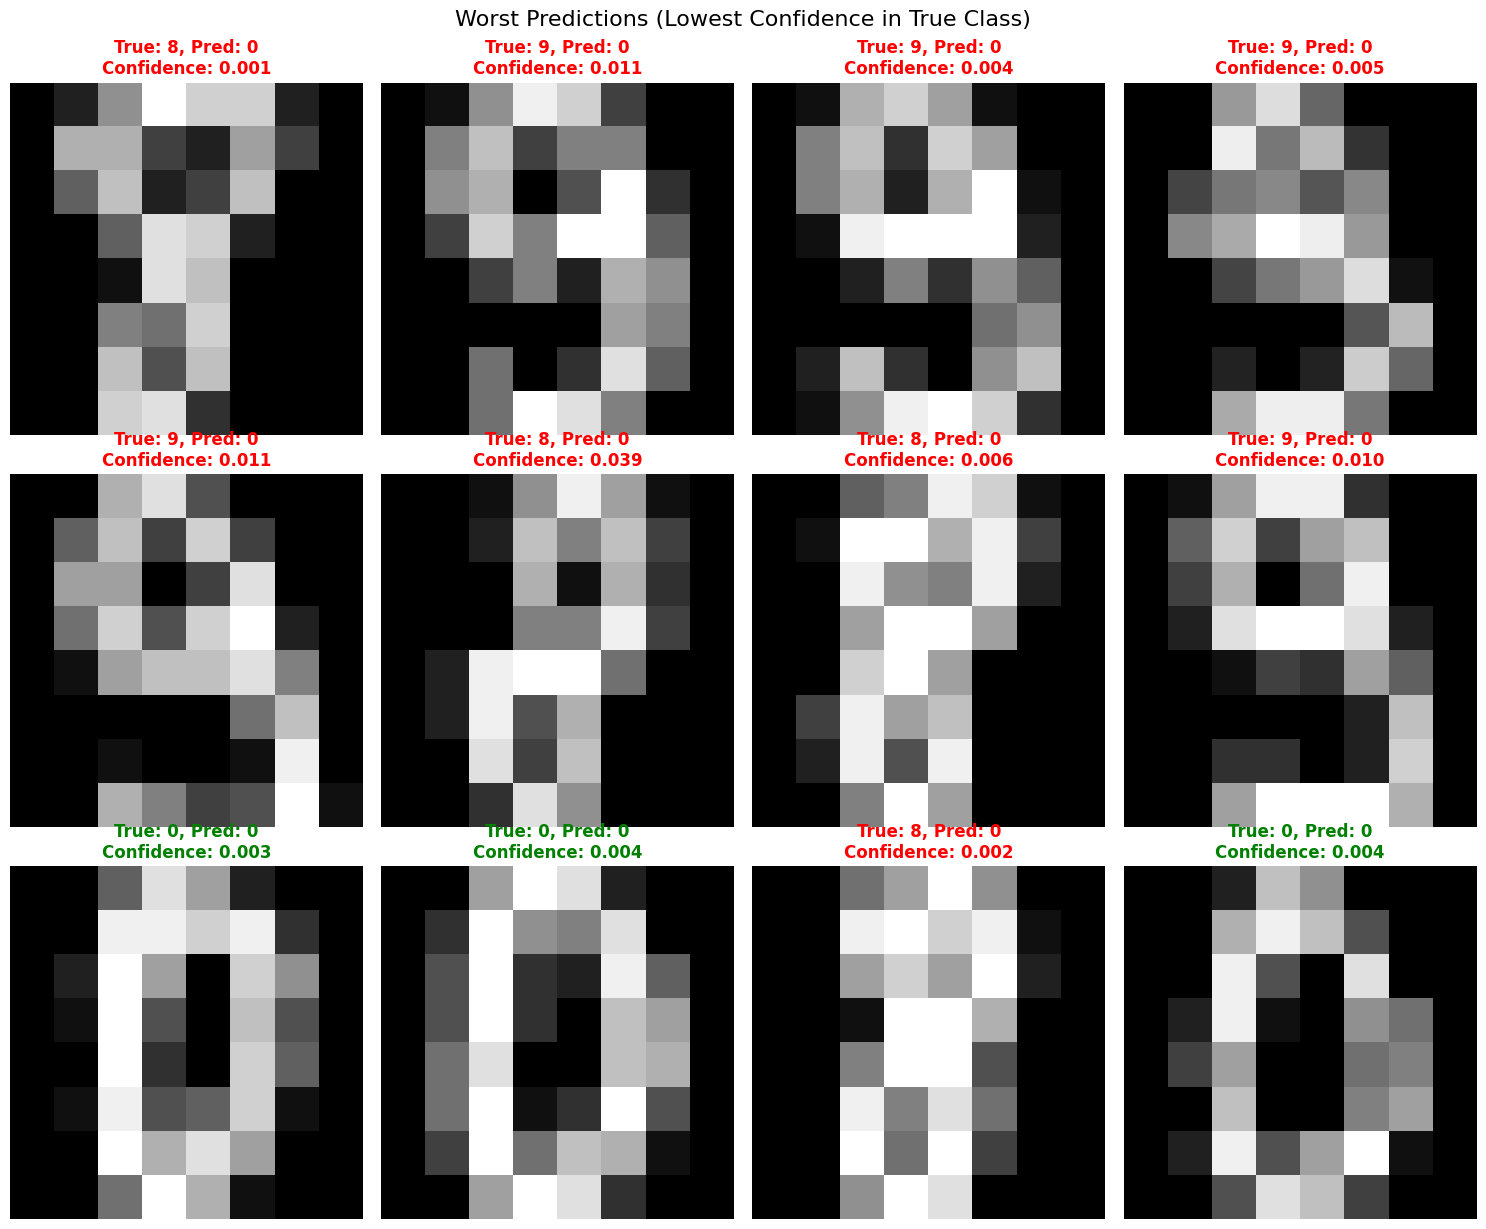

In [954]:
# Your code here

def plot_prediction_simple(model, X, y_true, index, ax=None):
    """
    Simple version that automatically handles image reshaping.
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    # Get the sample
    sample = X[index]
    n_features = sample.shape[0]
    
    # Common image sizes
    if n_features == 784:  # Standard MNIST
        img = sample.reshape(28, 28)
    elif n_features == 64:  # 8x8 images (like digits dataset)
        img = sample.reshape(8, 8)
    elif n_features == 1024:  # 32x32 images
        img = sample.reshape(32, 32)
    else:
        # Try to find the best square shape
        side = int(np.sqrt(n_features))
        if side * side == n_features:
            img = sample.reshape(side, side)
        else:
            # Use the closest square
            side = int(np.sqrt(n_features))
            img = sample[:side*side].reshape(side, side)
    
    # Get prediction
    sample_batch = sample.reshape(1, -1)
    probs = model.forward(sample_batch)[0]
    prediction = np.argmax(probs)
    confidence = np.max(probs)
    true_label = y_true[index]
    
    # Plot
    ax.imshow(img, cmap='gray')
    
    title = f'True: {true_label}, Pred: {prediction}\nConfidence: {confidence:.3f}'
    color = 'green' if prediction == true_label else 'red'
    ax.set_title(title, color=color, fontweight='bold')
    ax.axis('off')
    
    return prediction, confidence, true_label

# Use the simple version for plotting
print("\nUsing simple plotting function...")
n_plot = min(12, len(worst_indices))
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()

for i, (idx, ax) in enumerate(zip(worst_indices[:n_plot], axes)):
    plot_prediction_simple(model, X_test, y_test, idx, ax)

plt.tight_layout()
plt.suptitle('Worst Predictions (Lowest Confidence in True Class)', fontsize=16, y=1.02)
plt.show()

### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [ ]:
Answer: the best test accuracy I can achieve is around 0.6 with the tuning of hyperparameters and increasing hidden units.

In [955]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import itertools

class EnhancedNeuralNetwork:
    def __init__(self, input_size, hidden_sizes=[64], output_size=1, 
                 learning_rate=0.01, activation='relu', random_state=36):
        """
        Enhanced neural network with support for multiple hidden layers
        
        Parameters:
        input_size: number of input features
        hidden_sizes: list of integers specifying sizes of hidden layers
        output_size: number of output neurons
        learning_rate: learning rate for gradient descent
        activation: activation function ('relu', 'sigmoid', 'tanh')
        """
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.activation_type = activation
        self.random_state = random_state
        np.random.seed(random_state)
        
        # Initialize weights and biases
        self.weights = []
        self.biases = []
        
        # Input to first hidden layer
        layer_sizes = [input_size] + hidden_sizes + [output_size]
        
        for i in range(len(layer_sizes) - 1):
            # He initialization for ReLU, Xavier for sigmoid/tanh
            if activation == 'relu':
                scale = np.sqrt(2.0 / layer_sizes[i])
            else:
                scale = np.sqrt(1.0 / layer_sizes[i])
            
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * scale)
            self.biases.append(np.zeros((1, layer_sizes[i+1])))
    
    def activation(self, x):
        """Activation function"""
        if self.activation_type == 'relu':
            return np.maximum(0, x)
        elif self.activation_type == 'sigmoid':
            return 1 / (1 + np.exp(-np.clip(x, -250, 250)))  # Clip to prevent overflow
        elif self.activation_type == 'tanh':
            return np.tanh(x)
        else:
            raise ValueError("Unsupported activation function")
    
    def activation_derivative(self, x):
        """Derivative of activation function"""
        if self.activation_type == 'relu':
            return (x > 0).astype(float)
        elif self.activation_type == 'sigmoid':
            sig = self.activation(x)
            return sig * (1 - sig)
        elif self.activation_type == 'tanh':
            return 1 - np.tanh(x) ** 2
        else:
            raise ValueError("Unsupported activation function")
    
    def forward(self, X):
        """Forward propagation"""
        self.activations = [X]
        self.z_values = []
        
        current_activation = X
        
        # Hidden layers
        for i in range(len(self.weights) - 1):
            z = np.dot(current_activation, self.weights[i]) + self.biases[i]
            self.z_values.append(z)
            current_activation = self.activation(z)
            self.activations.append(current_activation)
        
        # Output layer (linear activation for regression, sigmoid for binary classification)
        z_output = np.dot(current_activation, self.weights[-1]) + self.biases[-1]
        self.z_values.append(z_output)
        
        # For binary classification, use sigmoid; for regression, use linear
        if self.output_size == 1:
            output_activation = 1 / (1 + np.exp(-np.clip(z_output, -250, 250)))
        else:
            output_activation = z_output  # Linear activation for regression/multi-class
        
        self.activations.append(output_activation)
        
        return self.activations[-1]
    
    def compute_loss(self, y_true, y_pred):
        """Compute binary cross-entropy loss for classification"""
        # Add small epsilon to prevent log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def backward(self, X, y_true, y_pred):
        """Backward propagation"""
        m = X.shape[0]
        gradients_w = [np.zeros_like(w) for w in self.weights]
        gradients_b = [np.zeros_like(b) for b in self.biases]
        
        # Output layer gradient
        if self.output_size == 1:  # Binary classification
            dz_output = y_pred - y_true
        else:  # Regression or multi-class
            dz_output = 2 * (y_pred - y_true) / m  # MSE derivative
        
        gradients_w[-1] = np.dot(self.activations[-2].T, dz_output) / m
        gradients_b[-1] = np.sum(dz_output, axis=0, keepdims=True) / m
        
        # Backpropagate through hidden layers
        dz = dz_output
        for i in range(len(self.weights) - 2, -1, -1):
            da = np.dot(dz, self.weights[i+1].T)
            dz = da * self.activation_derivative(self.z_values[i])
            gradients_w[i] = np.dot(self.activations[i].T, dz) / m
            gradients_b[i] = np.sum(dz, axis=0, keepdims=True) / m
        
        return gradients_w, gradients_b
    
    def update_parameters(self, gradients_w, gradients_b):
        """Update weights and biases"""
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * gradients_w[i]
            self.biases[i] -= self.learning_rate * gradients_b[i]
    
    def fit(self, X, y, epochs=1000, batch_size=32, validation_data=None, verbose=True):
        """Train the model"""
        losses = []
        val_losses = []
        accuracies = []
        val_accuracies = []
        
        for epoch in range(epochs):
            # Mini-batch training
            indices = np.random.permutation(X.shape[0])
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            for i in range(0, X.shape[0], batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]
                
                # Forward pass
                y_pred_batch = self.forward(X_batch)
                
                # Backward pass
                gradients_w, gradients_b = self.backward(X_batch, y_batch, y_pred_batch)
                
                # Update parameters
                self.update_parameters(gradients_w, gradients_b)
            
            # Compute losses and metrics
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            losses.append(loss)
            
            # Convert probabilities to binary predictions for accuracy
            y_pred_binary = (y_pred > 0.5).astype(int)
            accuracy = accuracy_score(y, y_pred_binary)
            accuracies.append(accuracy)
            
            # Validation metrics
            if validation_data is not None:
                X_val, y_val = validation_data
                y_val_pred = self.forward(X_val)
                val_loss = self.compute_loss(y_val, y_val_pred)
                val_losses.append(val_loss)
                
                y_val_pred_binary = (y_val_pred > 0.5).astype(int)
                val_accuracy = accuracy_score(y_val, y_val_pred_binary)
                val_accuracies.append(val_accuracy)
            
            if verbose and epoch % 100 == 0:
                if validation_data is not None:
                    print(f"Epoch {epoch}: Loss = {loss:.4f}, Acc = {accuracy:.4f}, "
                          f"Val Loss = {val_loss:.4f}, Val Acc = {val_accuracy:.4f}")
                else:
                    print(f"Epoch {epoch}: Loss = {loss:.4f}, Acc = {accuracy:.4f}")
        
        history = {
            'loss': losses,
            'accuracy': accuracies,
            'val_loss': val_losses if validation_data else None,
            'val_accuracy': val_accuracies if validation_data else None
        }
        
        return history
    
    def predict(self, X):
        """Make predictions"""
        y_pred = self.forward(X)
        return (y_pred > 0.5).astype(int)
    
    def predict_proba(self, X):
        """Predict probabilities"""
        return self.forward(X)

def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot loss
    axes[0].plot(history['loss'], label='Training Loss')
    if history['val_loss']:
        axes[0].plot(history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot accuracy
    axes[1].plot(history['accuracy'], label='Training Accuracy')
    if history['val_accuracy']:
        axes[1].plot(history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

class HyperparameterTuner:
    def __init__(self, X_train, y_train, X_val, y_val):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.results = []
    
    def experiment(self, hidden_sizes_list, learning_rates, activations, 
                   epochs=500, batch_size=32, verbose=False):
        """
        Run hyperparameter experiments
        
        Parameters:
        hidden_sizes_list: list of hidden layer configurations
        learning_rates: list of learning rates to try
        activations: list of activation functions to try
        """
        best_accuracy = 0
        best_params = None
        best_model = None
        
        print("Starting hyperparameter tuning...")
        print("=" * 60)
        
        for hidden_sizes, lr, activation in itertools.product(hidden_sizes_list, learning_rates, activations):
            print(f"Testing: hidden_sizes={hidden_sizes}, lr={lr}, activation={activation}")
            
            try:
                # Create and train model
                model = EnhancedNeuralNetwork(
                    input_size=self.X_train.shape[1],
                    hidden_sizes=hidden_sizes,
                    output_size=1,
                    learning_rate=lr,
                    activation=activation
                )
                
                history = model.fit(
                    self.X_train, self.y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(self.X_val, self.y_val),
                    verbose=False
                )
                
                # Get final validation accuracy
                val_accuracy = history['val_accuracy'][-1] if history['val_accuracy'] else 0
                train_accuracy = history['accuracy'][-1]
                
                # Store results
                result = {
                    'hidden_sizes': hidden_sizes,
                    'learning_rate': lr,
                    'activation': activation,
                    'train_accuracy': train_accuracy,
                    'val_accuracy': val_accuracy,
                    'model': model,
                    'history': history
                }
                self.results.append(result)
                
                print(f"  Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")
                
                # Update best model
                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = {
                        'hidden_sizes': hidden_sizes,
                        'learning_rate': lr,
                        'activation': activation
                    }
                    best_model = model
                    
            except Exception as e:
                print(f"  Error: {e}")
                continue
        
        print("=" * 60)
        print(f"Best validation accuracy: {best_accuracy:.4f}")
        print(f"Best parameters: {best_params}")
        
        return best_model, best_params, self.results
    
    def plot_results(self):
        """Plot results of hyperparameter tuning"""
        if not self.results:
            print("No results to plot. Run experiments first.")
            return
        
        # Create summary plot
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Extract data for plotting
        hidden_configs = [str(r['hidden_sizes']) for r in self.results]
        learning_rates = [r['learning_rate'] for r in self.results]
        val_accuracies = [r['val_accuracy'] for r in self.results]
        train_accuracies = [r['train_accuracy'] for r in self.results]
        
        # Plot 1: Validation accuracy by hidden layer configuration
        unique_configs = list(set(hidden_configs))
        config_accuracies = {}
        for config, acc in zip(hidden_configs, val_accuracies):
            if config not in config_accuracies:
                config_accuracies[config] = []
            config_accuracies[config].append(acc)
        
        config_means = [np.mean(config_accuracies[config]) for config in unique_configs]
        axes[0, 0].bar(unique_configs, config_means, alpha=0.7)
        axes[0, 0].set_title('Average Validation Accuracy by Hidden Layer Configuration')
        axes[0, 0].set_ylabel('Validation Accuracy')
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # Plot 2: Learning rate vs accuracy
        axes[0, 1].scatter(learning_rates, val_accuracies, alpha=0.6)
        axes[0, 1].set_xscale('log')
        axes[0, 1].set_xlabel('Learning Rate (log scale)')
        axes[0, 1].set_ylabel('Validation Accuracy')
        axes[0, 1].set_title('Learning Rate vs Validation Accuracy')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Plot 3: Train vs Validation accuracy
        axes[1, 0].scatter(train_accuracies, val_accuracies, alpha=0.6)
        axes[1, 0].plot([0, 1], [0, 1], 'r--', alpha=0.8)
        axes[1, 0].set_xlabel('Training Accuracy')
        axes[1, 0].set_ylabel('Validation Accuracy')
        axes[1, 0].set_title('Training vs Validation Accuracy')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Plot 4: Top 10 configurations
        top_results = sorted(self.results, key=lambda x: x['val_accuracy'], reverse=True)[:10]
        top_configs = [f"LR:{r['learning_rate']}\n{r['activation']}\n{r['hidden_sizes']}" 
                      for r in top_results]
        top_accuracies = [r['val_accuracy'] for r in top_results]
        
        axes[1, 1].barh(range(len(top_configs)), top_accuracies, alpha=0.7)
        axes[1, 1].set_yticks(range(len(top_configs)))
        axes[1, 1].set_yticklabels(top_configs, fontsize=8)
        axes[1, 1].set_xlabel('Validation Accuracy')
        axes[1, 1].set_title('Top 10 Hyperparameter Configurations')
        
        plt.tight_layout()
        plt.show()

# Example usage and comprehensive experimentation:
def run_comprehensive_experiments(X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Run comprehensive hyperparameter experiments
    """
    # Define hyperparameter search space
    hidden_sizes_list = [
        [32],           # Single hidden layer, small
        [64],           # Single hidden layer, medium  
        [128],          # Single hidden layer, large
        [32, 16],       # Two hidden layers, decreasing
        [64, 32],       # Two hidden layers, medium
        [128, 64],      # Two hidden layers, large
        [64, 32, 16],   # Three hidden layers
        [32, 32],       # Two equal hidden layers
        [64, 64],       # Two equal medium layers
    ]
    
    learning_rates = [0.1, 0.01, 0.001, 0.0001]
    activations = ['relu', 'sigmoid', 'tanh']
    
    # Initialize tuner
    tuner = HyperparameterTuner(X_train, y_train, X_val, y_val)
    
    # Run experiments
    best_model, best_params, all_results = tuner.experiment(
        hidden_sizes_list=hidden_sizes_list,
        learning_rates=learning_rates,
        activations=activations,
        epochs=300,
        batch_size=32,
        verbose=True
    )
    
    # Plot results
    tuner.plot_results()
    
    # Evaluate best model on test set
    y_test_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    print("\n" + "=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)
    print(f"Best Hyperparameters: {best_params}")
    print(f"Validation Accuracy: {max([r['val_accuracy'] for r in all_results]):.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    
    # Plot training history of best model
    best_result = next(r for r in all_results if 
                      r['hidden_sizes'] == best_params['hidden_sizes'] and
                      r['learning_rate'] == best_params['learning_rate'] and
                      r['activation'] == best_params['activation'])
    
    plot_training_history(best_result['history'])
    
    return best_model, best_params, all_results, test_accuracy

# Quick experimentation function for faster results:
def quick_hyperparameter_search(X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Quick hyperparameter search for faster results
    """
    print("Running quick hyperparameter search...")
    
    # Smaller search space for quick results
    hidden_sizes_list = [[32], [64], [32, 16], [64, 32]]
    learning_rates = [0.1, 0.01, 0.001]
    activations = ['relu', 'sigmoid']
    
    tuner = HyperparameterTuner(X_train, y_train, X_val, y_val)
    
    best_model, best_params, all_results = tuner.experiment(
        hidden_sizes_list=hidden_sizes_list,
        learning_rates=learning_rates,
        activations=activations,
        epochs=200,
        batch_size=32
    )
    
    # Test accuracy
    y_test_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    print(f"\nQuick Search Results:")
    print(f"Best Test Accuracy: {test_accuracy:.4f}")
    print(f"Best Parameters: {best_params}")
    
    return best_model, test_accuracy

